os → work with folders and file paths.
numpy → numerical operations and image arrays.
matplotlib → display images and graphs.
PIL.Image → open image files.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Defining dataset paths - Instead of repeatedly typing long folder paths, we store them in variables.

In [2]:
train_dir = "/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/datasets/chest_xray/train"
test_dir = "/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/datasets/chest_xray/test"
val_dir = "/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/datasets/chest_xray/val"

In [3]:
normal_train = len(os.listdir(os.path.join(train_dir, "NORMAL")))
pneumonia_train = len(os.listdir(os.path.join(train_dir, "PNEUMONIA")))
print("Normal Images:", normal_train)
print("Pneumonia Images:", pneumonia_train)

Normal Images: 1342
Pneumonia Images: 3876


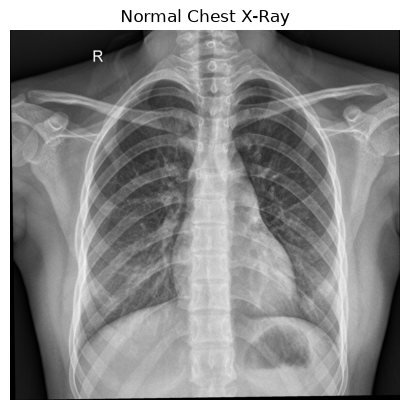

In [4]:
normal_path = os.path.join(
    train_dir,
    "NORMAL",
    os.listdir(os.path.join(train_dir, "NORMAL"))[0]
)
img = Image.open(normal_path)
plt.imshow(img, cmap="gray")
plt.title("Normal Chest X-Ray")
plt.axis("off")
plt.show()

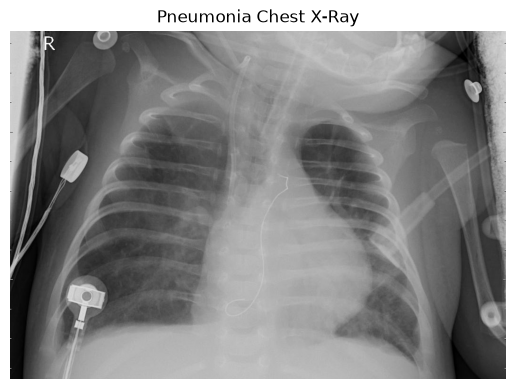

In [5]:
pneumonia_path = os.path.join(
    train_dir,
    "PNEUMONIA",
    os.listdir(os.path.join(train_dir, "PNEUMONIA"))[0]
)
img = Image.open(pneumonia_path)
plt.imshow(img, cmap="gray")
plt.title("Pneumonia Chest X-Ray")
plt.axis("off")
plt.show()

In [6]:
img = Image.open(normal_path)
print("Image Size:", img.size)

Image Size: (2359, 2234)


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [9]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.


In [10]:
validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 16 images belonging to 2 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [12]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [13]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 150, 150, 3)
(32,)


CNN - lesson 4

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [15]:
model = Sequential()
# First Convolution Layer
model.add(
    Conv2D( 32, (3,3), activation='relu', input_shape=(150,150,3) )
)
model.add(MaxPooling2D(pool_size=(2,2)))
# Second Convolution Layer
model.add(
    Conv2D( 64, (3,3), activation='relu'
    )
)
model.add(MaxPooling2D(pool_size=(2,2)))
# Third Convolution Layer
model.add(
    Conv2D( 128, (3,3), activation='relu')
)
model.add(MaxPooling2D(pool_size=(2,2)))
# Convert feature maps into a vector
model.add(Flatten())
# Fully Connected Layer
model.add(Dense(128, activation='relu'))
# Reduce overfitting
model.add(Dropout(0.5))
# Output Layer
model.add(Dense(1, activation='sigmoid'))

/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Lesson 5 

In [18]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.7849 - loss: 0.4726 - val_accuracy: 0.6250 - val_loss: 0.8434
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 257ms/step - accuracy: 0.8727 - loss: 0.2982 - val_accuracy: 0.7500 - val_loss: 0.5449
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.8997 - loss: 0.2408 - val_accuracy: 0.8125 - val_loss: 0.6451
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 265ms/step - accuracy: 0.9064 - loss: 0.2295 - val_accuracy: 0.7500 - val_loss: 0.8121
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 274ms/step - accuracy: 0.9162 - loss: 0.2128 - val_accuracy: 0.7500 - val_loss: 0.5771
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 274ms/step - accuracy: 0.9222 - loss: 0.2017 - val_accuracy: 0.8125 - val_loss: 0.5103
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 275ms/step - accuracy: 0.9239 - loss: 0.1956 - val_accuracy: 0.8125 - val_loss: 0.5209
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 291ms/step - accuracy: 0.9241 - loss: 0

In [20]:
model.save("/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/models/pneumonia_cnn.keras")

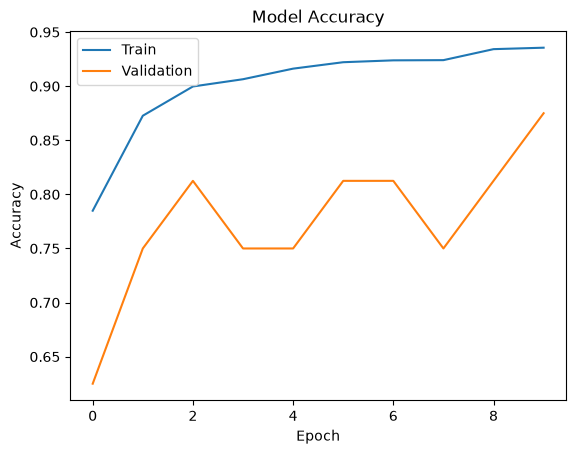

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
plt.show()

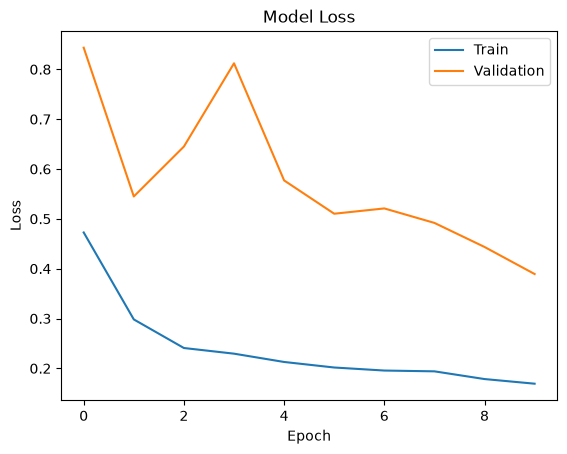

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(['Train', 'Validation'])
plt.show()

Lesson 6

In [23]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8894 - loss: 0.2994
Test Loss: 0.2993873357772827
Test Accuracy: 0.8894230723381042


In [24]:
predictions = model.predict(test_generator)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


In [25]:
predicted_classes = (predictions > 0.5).astype(int)

In [26]:
true_classes = test_generator.classes

In [27]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

[[176  58]
 [ 11 379]]


In [28]:
from sklearn.metrics import classification_report
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=["NORMAL", "PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.94      0.75      0.84       234
   PNEUMONIA       0.87      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.88       624
weighted avg       0.89      0.89      0.89       624



In [30]:
model.save("/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/models/pneumonia_cnn.keras")

In [31]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [32]:
model = load_model("/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/models/pneumonia_cnn.keras")

In [33]:
img_path = "/Users/vajja.nehapranathi/Downloads/PneumoniaDetection/datasets/chest_xray/test/NORMAL/IM-0009-0001.jpeg"

In [34]:
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [35]:
prediction = model.predict(img_array)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[[0.09817781]]


In [36]:
if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

Prediction: NORMAL


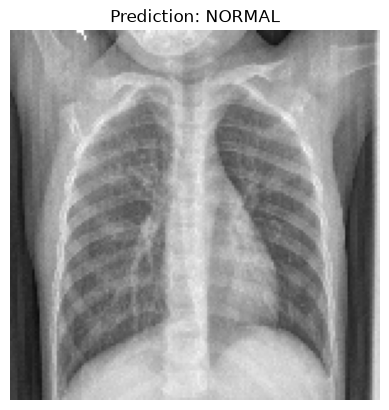

In [37]:
plt.imshow(img, cmap="gray")
plt.title(
    "Prediction: PNEUMONIA"
    if prediction[0][0] > 0.5
    else "Prediction: NORMAL"
)
plt.axis("off")
plt.show()